# Phase III: Envelope optimization integrated into surroundings

**Building:** Linear Building · **Model:** `models/linear_envelope_wwr20.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/linear_envelope_wwr20_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with nine envelope and natural-ventilation variables. Run this notebook from its own folder (paths are relative to `notebooks/`).

## Envelope optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation Model

In [2]:
building = ef.get_building('../models/linear_envelope_wwr20.idf') # Loading the E+ model;

### Variables

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_north",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - North Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_south",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - South Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_east",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - East Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_west",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - West Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_roof",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Ext mortar",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Fibercement tile",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="WINDOWMATERIAL:GLAZING",   # Class of E+;
                    object_name="Clear 3mm",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='Glazing - Thickness',
                value_descriptor=RangeParameter(min_val=0.003, max_val=0.01)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="SCHEDULE:COMPACT",             # Class of E+;
                    object_name="VN_19",    # Object name;
                    field_name="Field 4", # Object field;
                ),
                name='AFN - Setpoint',
                value_descriptor=RangeParameter(min_val=18, max_val=25)      # Range
                )
            )


### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=500, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

1 day, 5:59:11.858565


### Results

In [6]:
results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.148846,0.141822,0.102753,0.146515,0.138799,0.617113,0.775552,0.008989,24.232504,2.117032e+11,8.320364e+08,0,True
1,0.009644,0.006302,0.083374,0.022409,0.073872,0.202000,0.225584,0.003094,19.787347,7.805386e+10,1.545577e+11,0,True
2,0.023394,0.022886,0.038529,0.070482,0.099926,0.215684,0.234352,0.003173,20.415099,8.307667e+10,1.288783e+11,0,True
3,0.005369,0.114285,0.107285,0.072254,0.048592,0.223818,0.441691,0.008977,21.301922,8.363138e+10,4.975108e+10,0,True
4,0.149495,0.094888,0.007667,0.072695,0.109165,0.617102,0.652937,0.008536,22.974793,1.490054e+11,1.065882e+09,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.028278,0.072998,0.060310,0.032645,0.010865,0.204797,0.334055,0.003117,21.786892,8.855640e+10,2.628101e+10,0,False
96,0.113203,0.100483,0.116513,0.072695,0.090550,0.736186,0.454692,0.008600,22.682237,1.316781e+11,1.997095e+09,0,False
97,0.003484,0.095294,0.091251,0.077018,0.061111,0.249897,0.226984,0.006901,20.029063,8.046088e+10,1.711096e+11,0,False
98,0.132133,0.146788,0.131078,0.137502,0.082941,0.757956,0.515530,0.009351,22.764953,1.372789e+11,1.531652e+09,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/884)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/884)

results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.148846,0.141822,0.102753,0.146515,0.138799,0.617113,0.775552,0.008989,24.232504,67.119167,0.263792,0,True
1,0.009644,0.006302,0.083374,0.022409,0.073872,0.202000,0.225584,0.003094,19.787347,24.746480,49.001543,0,True
2,0.023394,0.022886,0.038529,0.070482,0.099926,0.215684,0.234352,0.003173,20.415099,26.338929,40.860039,0,True
3,0.005369,0.114285,0.107285,0.072254,0.048592,0.223818,0.441691,0.008977,21.301922,26.514795,15.773264,0,True
4,0.149495,0.094888,0.007667,0.072695,0.109165,0.617102,0.652937,0.008536,22.974793,47.241215,0.337931,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.028278,0.072998,0.060310,0.032645,0.010865,0.204797,0.334055,0.003117,21.786892,28.076243,8.332227,0,False
96,0.113203,0.100483,0.116513,0.072695,0.090550,0.736186,0.454692,0.008600,22.682237,41.747696,0.633166,0,False
97,0.003484,0.095294,0.091251,0.077018,0.061111,0.249897,0.226984,0.006901,20.029063,25.509610,54.249194,0,False
98,0.132133,0.146788,0.131078,0.137502,0.082941,0.757956,0.515530,0.009351,22.764953,43.523411,0.485600,0,False


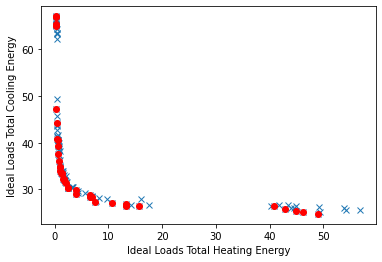

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/linear_envelope_wwr20_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

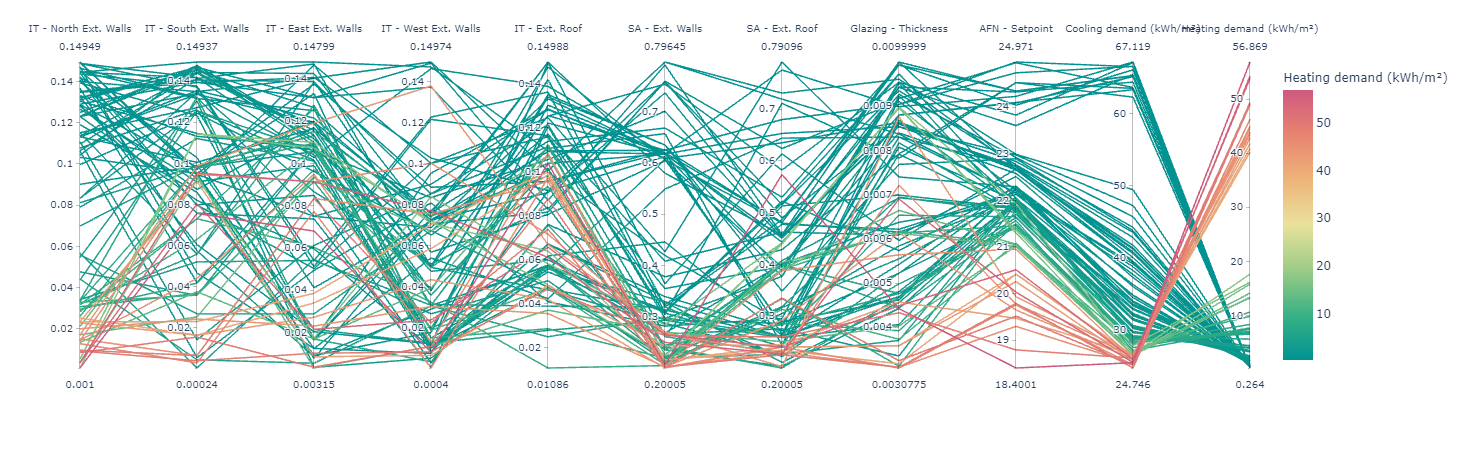

In [9]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["IT - North Ext. Walls","IT - South Ext. Walls","IT - East Ext. Walls","IT - West Ext. Walls","IT - Ext. Roof","SA - Ext. Walls","SA - Ext. Roof", "Glazing - Thickness", "AFN - Setpoint", "Cooling demand (kWh/m²)","Heating demand (kWh/m²)" ],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

In [10]:
optres

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.148846,0.141822,0.102753,0.146515,0.138799,0.617113,0.775552,0.008989,24.232504,67.119167,0.263792,0,True
1,0.009644,0.006302,0.083374,0.022409,0.073872,0.202000,0.225584,0.003094,19.787347,24.746480,49.001543,0,True
2,0.023394,0.022886,0.038529,0.070482,0.099926,0.215684,0.234352,0.003173,20.415099,26.338929,40.860039,0,True
3,0.005369,0.114285,0.107285,0.072254,0.048592,0.223818,0.441691,0.008977,21.301922,26.514795,15.773264,0,True
4,0.149495,0.094888,0.007667,0.072695,0.109165,0.617102,0.652937,0.008536,22.974793,47.241215,0.337931,0,True
5,0.142093,0.102806,0.016319,0.077204,0.133106,0.617102,0.442998,0.008799,24.090434,65.091279,0.310155,0,True
6,0.139365,0.123235,0.016456,0.095447,0.128554,0.608387,0.634904,0.008635,22.835878,44.223684,0.402147,0,True
7,0.028867,0.062984,0.107143,0.018878,0.047070,0.206275,0.313269,0.003728,21.078663,27.101035,10.619896,0,True
8,0.022887,0.016201,0.027170,0.043499,0.041967,0.200054,0.240625,0.003580,20.255245,25.747646,42.789999,0,True
9,0.026049,0.097660,0.109473,0.012216,0.056716,0.240750,0.200049,0.004669,21.565462,27.195804,7.442028,0,True


In [11]:
results.to_csv('../results/linear_envelope_wwr20_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
22,0.079023,0.112069,0.101128,0.010135,0.057516,0.235636,0.203515,0.004427,21.915472,30.227558,2.510329,0,True
